<a href="https://colab.research.google.com/github/ByungChul-Cha/Deep_Learning_Study/blob/main/Day06/08_%ED%95%A9%EC%84%B1%EA%B3%B1_%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **08-01. Convolution & Pooling(합성곱과 풀링)**

# 합성곱 신경망의 대두
- 이미지 처리에 탁월한 성는을 보이는 신경망
- 합성곱층과 풀링층으로 구성
  - 합성곱층: 합성곱 연산과 그 결과가 활성화 함수를 지남
  - 풀링층: 풀링 연산을 함
- 다층 퍼셉트론은 몇 가지 픽셀만 달라져도 민감하게 예측에 영향을 받는 단점 존재
  - 공간적인 구조 정보가 유실됨
  - 공간적인 구조 정보를 보존하면서 학습할 수 있는 방법 필요

# Channel(채널)
- 이미지: (높이, 넓이, 채널) or (높이, 넓이, 깊이) -> 3차원 텐서
  - 높이: 세로 방향 픽셀 수
  - 넓이: 가로 방향 픽셀 수
  - 채널: 색 성분 (흑백 이미지는 채널 수가 1)

# Convolution operation(합성곱 연산)
- 합성곱층은 합성곱 연산을 통해 이미지의 특징을 추출
- 커널(kernel) 또는 필터(filter)라는 n x m 크기의 행렬을 사용
- 특성 맵(feature map): 합성곱 연산을 통해 나온 결과
- 커널의 크기는 사용자가 정할 수 있음
- 스트라이드(stride): 커널의 이동 범위, 사용자가 정할 수 있음

# Padding(패딩)
- 특성 맵은 입력보다 크기가 작아짐
- 패딩: 입력의 가장자리에 지정된 개수의 폭만큼 행과 열을 추가
- 주로 zero padding 사용

# 가중치와 편향
- 합성곱 연산에서는 커널의 크기만큼 가중치 사용
- 합성곱 신경망은 다층 퍼셉트론을 사용할 때보다 훨씬 적은 수의 가중치 사용
  - 공간적 구조 정보를 보존
- 비선형성 추가를 위해서 활성화 함수를 지나게 됨
  - ReLU 함수나 ReLU의 변형들이 주로 사용
- 편향은 하나의 값만 존재하며, 커널이 적용된 결과의 모든 원소에 더해짐

# 특성 맵의 크기 계산 방법
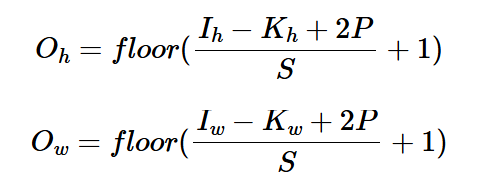
- Oₕ = 특성 맵의 높이
- Iₕ = 입력의 높이
- Kₕ = 커널의 높이
- P = 패딩의 폭
- S = 스트라이드

# 다수의 채널을 가질 경우의 합성곱 연산(3차원 텐서의 합성곱 연산)
- 커널의 채널 수도 입력의 채널 수만큼 존재해야 함
- 합성곱 연산을 채널마다 수행
- 그 결과를 모두 더하여 최종 특성맵을 구함
- **3개의 커널이 아니라 3개의 채널을 가진 1개의 커널**

# 3차원 텐서의 합성곱 연산
- 하나의 입력에 여러 개의 커널을 사용하는 합성곱 연산을 할 수 있음
- 합성곱 연산에서 다수의 커널을 사용할 경우
  - 사용한 커널 수는 특성 맵의 채널 수가 됨

# Pooling(풀링)
- 풀링층에서는 특성 맵을 다운샘플링하여 특성 맵의 크기를 줄이는 풀링 연산을 함
- 풀링 연산:
  - max pooling: 커널과 겹치는 영역 안에서 최대값을 추출
  - average pooling: 커널과 겹치는 영역 안에서 평균값을 추출
- 커널과 스트라이드의 개념 존재
- 합성곱 연산과의 차이점:
  - 학습해야 할 가중치가 없음
  - 연산 후에 채널 수가 변하지 않음

# **08-02. CNN으로 MNIST 분류하기**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
# 배치 크기 x 채널 x 높이 x 너비의 크기의 텐서를 선언
inputs = torch.Tensor(1, 1, 28, 28)
print("텐서의 크기: ",inputs.shape)

텐서의 크기:  torch.Size([1, 1, 28, 28])


In [ ]:
# 합성곱 층 정의
conv1 = nn.Conv2d(1, 32, 3, padding=1)
print(conv1)

conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
print(conv2)

pool = nn.MaxPool2d(2)
print(pool)

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [ ]:
# 합성곱 층 연결
out = conv1(inputs)
print(out.shape)

out = pool(out)
print(out.shape)

out = conv2(out)
print(out.shape)

out = pool(out)
print(out.shape)

torch.Size([1, 32, 28, 28])
torch.Size([1, 32, 14, 14])
torch.Size([1, 64, 14, 14])
torch.Size([1, 64, 7, 7])


In [ ]:
# 첫번째 차원인 배치 차원은 그대로 두고 나머지는 펼치기
out = out.view(out.size(0), -1)
print(out.shape)

torch.Size([1, 3136])


In [ ]:
# 전결합층 정의 및 연결
fc = nn.Linear(3136, 10)
out = fc(out)
print(out.shape)

torch.Size([1, 10])


# CNN으로 MNIST 분류하기

In [2]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn.init

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)

if device == 'cuda':
  torch.cuda.manual_seed_all(777)

In [4]:
learning_rate = 0.001
training_epochs = 15
batch_size = 100

In [5]:
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)
mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


In [6]:
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

In [9]:
class CNN(torch.nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.layer1 = torch.nn.Sequential(
        torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.layer2 = torch.nn.Sequential(
        torch.nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.fc = torch.nn.Linear(7 * 7 * 64, 10, bias=True)

    # 전결합층 한정으로 가중치 초기화
    torch.nn.init.xavier_uniform_(self.fc.weight)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc(out)
    return out

In [10]:
model = CNN().to(device)

In [11]:
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
total_batch = len(data_loader)
print('총 배치의 수 : {}'.format(total_batch))

총 배치의 수 : 600


In [13]:
for epoch in range(training_epochs):
  # 에포크당 평균 비용을 저장하기 위한 변수 초기화
  avg_cost = 0

  # 미니 배치 단위로 데이터를 꺼내옴.
  for X, Y in data_loader:
    X = X.to(device)
    Y = Y.to(device)

    optimizer.zero_grad()
    hypothesis = model(X)
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    avg_cost += cost / total_batch

  print("[Epoch: {:>4}] cost = {:>.9}".format(epoch + 1, avg_cost))

[Epoch:    1] cost = 0.225655422
[Epoch:    2] cost = 0.0631100982
[Epoch:    3] cost = 0.0463233925
[Epoch:    4] cost = 0.0374564826
[Epoch:    5] cost = 0.0314029492
[Epoch:    6] cost = 0.0261034314
[Epoch:    7] cost = 0.021981867
[Epoch:    8] cost = 0.0183512587
[Epoch:    9] cost = 0.0165750179
[Epoch:   10] cost = 0.0134417908
[Epoch:   11] cost = 0.0100245094
[Epoch:   12] cost = 0.00993742235
[Epoch:   13] cost = 0.00855708215
[Epoch:   14] cost = 0.00672064582
[Epoch:   15] cost = 0.00765485177


In [14]:
with torch.no_grad():
  X_test = mnist_test.test_data.view(len(mnist_test), 1, 28, 28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  prediction = model(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test

  accuracy = correct_prediction.float().mean()

  print("Accuracy:", accuracy.item())

Accuracy: 0.9878000020980835


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


# **08-03. 깊은 CNN으로 MNIST 분류하기**

In [15]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn.init

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)

if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [19]:
learning_rate = 0.001
training_epochs = 15
batch_size = 100

In [20]:
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

In [21]:
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

In [24]:
class Deep_CNN(torch.nn.Module):
  def __init__(self):
    super(Deep_CNN, self).__init__()
    # 드롭아웃 확률
    self.keep_prob = 0.5

    self.layer1 = torch.nn.Sequential(
        torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.layer2 = torch.nn.Sequential(
        torch.nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.layer3 = torch.nn.Sequential(
        torch.nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
    )

    self.fc1 = torch.nn.Linear(4 * 4 * 128, 625, bias=True)

    # 전결합층 한정으로 가중치 초기화
    torch.nn.init.xavier_uniform_(self.fc1.weight)

    self.layer4 = torch.nn.Sequential(
        self.fc1,
        torch.nn.ReLU(),
        torch.nn.Dropout(p=1 - self.keep_prob)
    )

    self.fc2 = torch.nn.Linear(625, 10, bias=True)
    torch.nn.init.xavier_uniform_(self.fc2.weight)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = self.layer3(out)
    out = out.view(out.size(0), -1)
    out = self.layer4(out)
    out = self.fc2(out)
    return out

In [31]:
deep_model = Deep_CNN().to(device)

In [32]:
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(deep_model.parameters(), lr=learning_rate)

In [33]:
total_batch = len(data_loader)
print(total_batch)

600


In [34]:
for epoch in range(training_epochs):
  avg_cost = 0

  for X, Y in data_loader:
    X = X.to(device)
    Y = Y.to(device)

    optimizer.zero_grad()
    hypothesis = deep_model(X)
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    avg_cost += cost / total_batch

  print("[Epoch: {:>4}] cost = {:>.9}".format(epoch + 1, avg_cost))

[Epoch:    1] cost = 0.196478978
[Epoch:    2] cost = 0.0534261055
[Epoch:    3] cost = 0.0366107114
[Epoch:    4] cost = 0.0278520677
[Epoch:    5] cost = 0.023958426
[Epoch:    6] cost = 0.0189053919
[Epoch:    7] cost = 0.018730944
[Epoch:    8] cost = 0.0148972804
[Epoch:    9] cost = 0.0125293629
[Epoch:   10] cost = 0.0123995533
[Epoch:   11] cost = 0.0114861997
[Epoch:   12] cost = 0.0092652943
[Epoch:   13] cost = 0.0100209499
[Epoch:   14] cost = 0.00768537447
[Epoch:   15] cost = 0.00737742661


In [35]:
with torch.no_grad():
  X_test = mnist_test.test_data.view(len(mnist_test), 1, 28, 28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  predicition = deep_model(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.9878000020980835


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
